In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

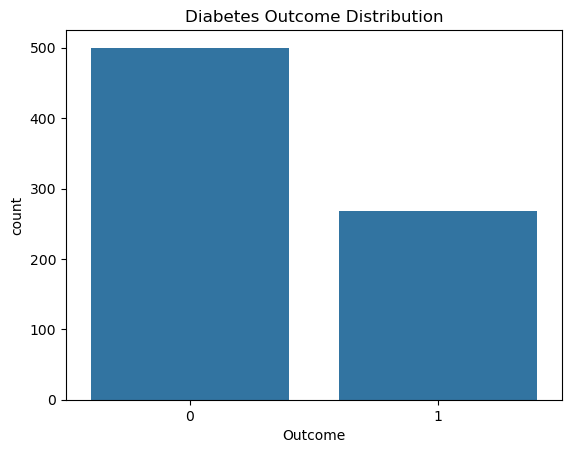

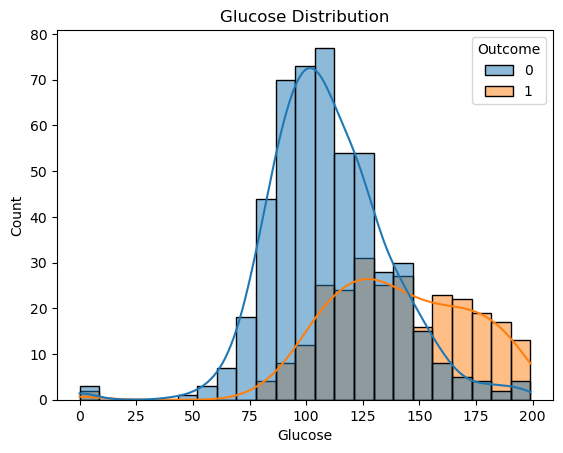

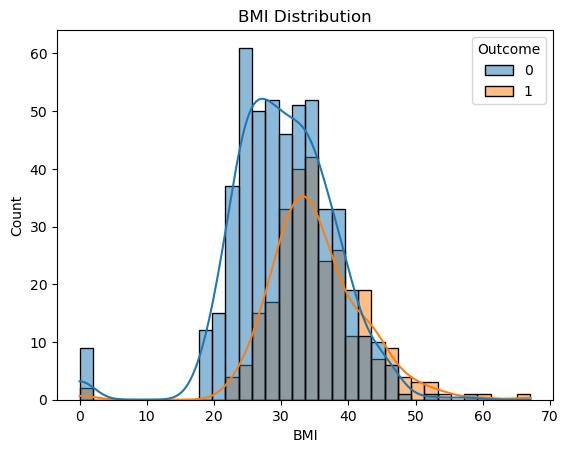

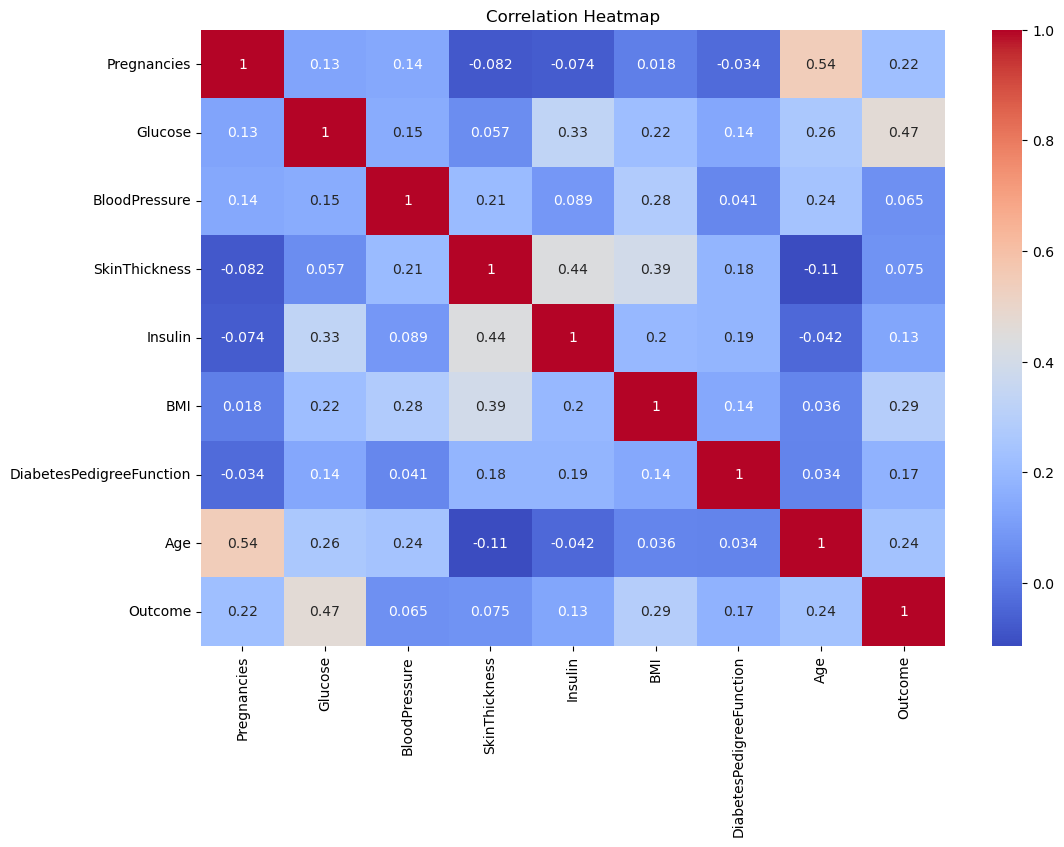

                    Feature  Importance
1                   Glucose    0.247375
5                       BMI    0.172144
7                       Age    0.143971
6  DiabetesPedigreeFunction    0.120427
2             BloodPressure    0.088419
0               Pregnancies    0.082032
4                   Insulin    0.077272
3             SkinThickness    0.068360


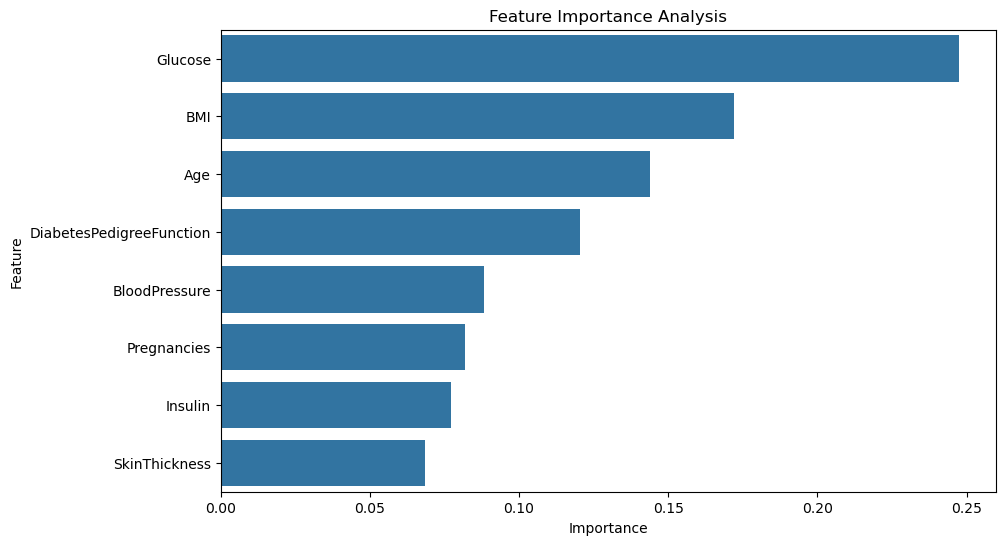

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from xgboost import XGBClassifier

# Load Dataset
df = pd.read_csv("diabetes.csv")

# Display Dataset
print(df.head())

# Dataset Info
print(df.info())

# Check Missing Values
print(df.isnull().sum())

# Features and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- Logistic Regression ----------------

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

# ---------------- Random Forest ----------------

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

# ---------------- XGBoost ----------------

xgb_model = XGBClassifier(eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

# ---------------- EDA ----------------

# Outcome Distribution
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

# Glucose Distribution
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True)
plt.title("Glucose Distribution")
plt.show()

# BMI Distribution
sns.histplot(data=df, x='BMI', hue='Outcome', kde=True)
plt.title("BMI Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

# ---------------- Feature Importance Analysis ----------------

importance = rf_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title("Feature Importance Analysis")

plt.show()